# PCHN63112 Workshop: Longitudinal Data Example

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Autism Data
The data we will use concern measurements of socialisation in 158 children diagnosed with autism spectrum disorder (ASD). The children were measured at ages 2, 3, 5, 9, and 13. The outcome variable is the Vineland Socialisation Age Equivalent (VSAE) score, which combines multiple assessments of socialisation at each age. Also of interest was the children's initial language development. This was measured using the Sequenced Inventory of Communication Development (SICD) at age 2 and the children were placed into groups depending upon whether they scored *low*, *medium* or *high* on the expressive language subscale. The main interest of the study was to assess how socialisation improved over time, as well as whether this improvement had any relationship with the child's initial language skills at age 2.

The data are available to download from [here](https://websites.umich.edu/~bwest/chapter6.html). Once downloaded to the current working directory, the code below will read the data in and then print the values for the first 3 children.

In [2]:
autism <- read.csv('autism.csv')
autism[1:14,]

   age vsae sicdegp childid
1    2    6       3       1
2    3    7       3       1
3    5   18       3       1
4    9   25       3       1
5   13   27       3       1
6    2   17       3       3
7    3   18       3       3
8    5   12       3       3
9    9   18       3       3
10  13   24       3       3
11   2   12       3       4
12   3   14       3       4
13   5   38       3       4
14   9  114       3       4

As this is already long-formatted, we just need to convert the relevant variables to factors. We also rename the levels associated with `sicdegp` factor to make their meaning clearer.

In [3]:
autism$childid <- as.factor(autism$childid)
autism$sicdegp <- as.factor(autism$sicdegp)

levels(autism$sicdegp) <- c('low','medium','high')
colnames(autism)       <- c('age','VSAE','SICDEGP','childid')

We can now briefly summarise all the variables to check everything is in order.

In [4]:
summary(autism)

      age              VSAE          SICDEGP       childid   
 Min.   : 2.000   Min.   :  1.00   low   :192   1      :  5  
 1st Qu.: 2.000   1st Qu.: 10.00   medium:255   2      :  5  
 Median : 4.000   Median : 14.00   high  :165   3      :  5  
 Mean   : 5.771   Mean   : 26.41                14     :  5  
 3rd Qu.: 9.000   3rd Qu.: 27.00                15     :  5  
 Max.   :13.000   Max.   :198.00                17     :  5  
                  NA's   :2                     (Other):582  

Of note is that VSAE has a very wide range, from 1-198, and also contains two missing values. This indicates that there were some occasions when a particular child was not measured. There are also more children in the `medium` SICDEGP group than the others, making the data *unbalanced* in relation to this factor. Also note that `childid` does not run sequentially, as these data represent a subset of children who participated in this study.

### Model Notation
As these data are a mixture of *categorical* and *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use *descriptive labels* rather than greek letter for categorical variables (e.g. $\text{SICDEGP}_{j}$ rather than $\alpha_{j}$) and will introduce $\beta$-coefficients for continuous variables (e.g. $\left(\beta_{1} \times \text{age}_{i}\right)$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which terms are categorical and which are continuous. In reality, the whole model is fit as a regression with dummy variables in place of the categorical predictors. However, it can be less clear to write the model this way, even if this is the reality of how it is fit.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness. 

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain the socialisation skills of children with ASD. The entities that our model is describing are the scores of the children, and so our units of analysis are the *children* themselves.   

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(autism)

  age VSAE SICDEGP childid
1   2    6    high       1
2   3    7    high       1
3   5   18    high       1
4   9   25    high       1
5  13   27    high       1
6   2   17    high       3

we can see that each row corresponds to a single unit (*child*) measured *multiple times*. So these are either *repeated measurements* or *longitudinal* data. The difference lies in whether there is an explicit measurement of time here. As we can see, the different repeats are indexed by the values of `age`. Importantly, these values have an *order* that must be maintained and the temporal gap between successive values is not uniform. The time scale is also meaningful, as it is measured in *years*. As such, this is *longitudinal* data.

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. The only potential candidate is `sicdegp`, but we know from the data description above that this is an artificial experimental grouping based on the child's language skills at age 2. It is not indicative of a shared context of environment that binds different children together. As such, this is clearly a *grouping* variable rather than a *clustering* variable. Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Longitudinal**  | 
|------------------|-------------------|
| **Dataset**      | `autism`          |
| **Level 1**      | Repeats over time |
| **Level 2**      | *Child*           |
| **Level 3**      | -                 |

Because these data are quite simple, we can get an initial sense of their structure by constructing a graph of child-specific trajectories over time for each level of `sicdegp`

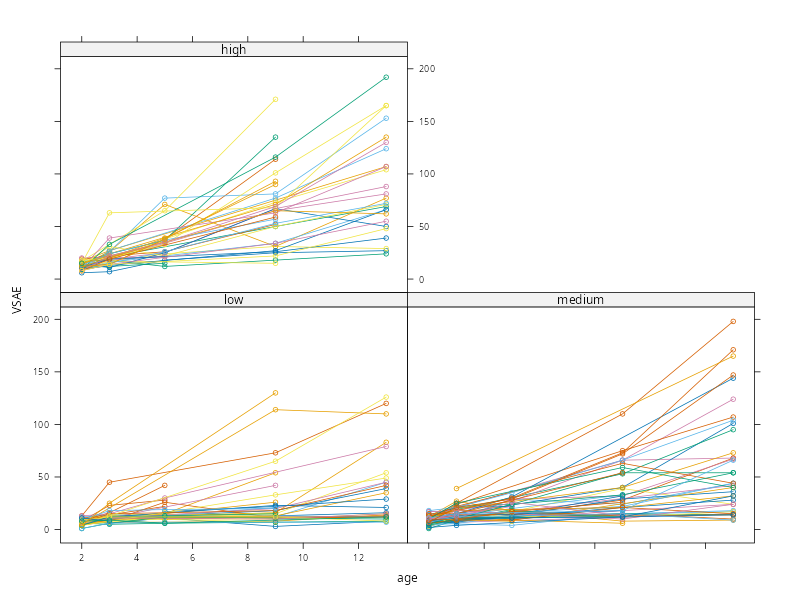

In [6]:
xyplot(
  VSAE ~ age|SICDEGP, # x-axis=age, panel=SICDe Group
  groups = childid,   # separate lines per-child
  data   = autism,    # data
  type   = "b"        # lines with points
)

Several patterns are noticeable here. Firstly, the variance appears to increase as a function of `age`, getting wider and wider as `age` increases. Whatever model we choose, we will need to make sure that the variance estimated for each value of time increase appropriately. Secondly, there is a slight hint that some of these trajectories are not *linear*, rather they *bend* upwards. As such, we may wish to entertain a *quadratic* model of time as well. Finally, it does not look as if the variance between these trajectories differs majorly between the levels of `sicdegp`, but this is something we could consider.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure which, in this example, is a single *child*. We choose the first child in the dataset, who is indexed using `childid == '1'`. We subset the data below

In [7]:
autism.1 <- subset(autism, childid=='1')
print(autism.1)

  age VSAE SICDEGP childid
1   2    6    high       1
2   3    7    high       1
3   5   18    high       1
4   9   25    high       1
5  13   27    high       1


In terms of those variables suitable for a model of an individual child, we note that `sicdegp` is constant, given that this is defined at the level of a *child* as a whole. As such, we remove it from the dataset

In [8]:
autism.1 <- subset(autism, childid=='1', select= -SICDEGP)
print(autism.1)

  age VSAE childid
1   2    6       1
2   3    7       1
3   5   18       1
4   9   25       1
5  13   27       1


Now we can see that the only variables left are the outcome variable `vsae` and the continuous time predictor of `age`. As such, our basic model for a single child is

$$
\text{VSAE}_{i} = \beta_{0} + \left(\beta_{1} \times \text{age}_{i}\right) + \eta_{i},
$$

which is just the simple regression of VSAE on age. We can fit this in `R` is we like, just to see that this works

In [9]:
autism.1.lm <- lm(VSAE ~ 1 + age, data=autism.1)
summary(autism.1.lm)


Call:
lm(formula = VSAE ~ 1 + age, data = autism.1)

Residuals:
     1      2      3      4      5 
-1.726 -2.743  4.224  3.156 -2.911 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   3.6923     3.2855   1.124   0.3429  
age           2.0168     0.4329   4.659   0.0187 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.949 on 3 degrees of freedom
Multiple R-squared:  0.8786,	Adjusted R-squared:  0.8381 
F-statistic:  21.7 on 1 and 3 DF,  p-value: 0.01866


which we could then plot, just to make the model as clear as possible.

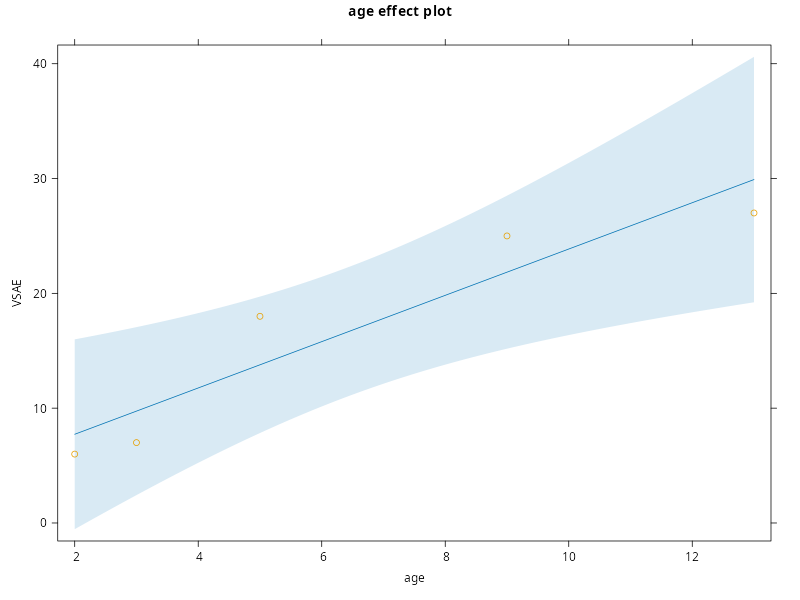

In [10]:
plot(allEffects(autism.1.lm, residuals=TRUE), partial.residuals=list(smooth=FALSE))

Notably, there is not a huge amount of data per-child. Only 5 datapoints, with some children having even fewer due to attrition over time. We can get a sense of the data within the whole sample by plotting a random subset of children 

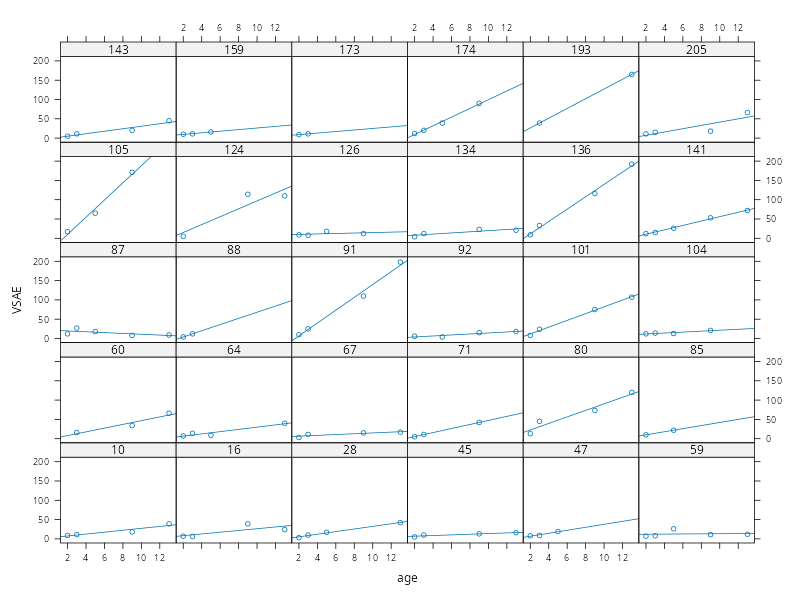

In [11]:
set.seed(666)
keep.IDs <- sample(unique(autism$childid), 30)  # select 30 random children IDs

xyplot(VSAE ~ age | childid,                    # x-axis=age, panels=child
  data = subset(autism, childid %in% keep.IDs), # only random child IDs
  type = c('p','r')                             # points and regression lines
)

In most cases, there is enough data to fit the model. Though in some, the fit will be *perfect* (e.g. child 173 and child 85). It is also notable from this visualisation illustrates how different the trajectories over time are for different children. Some show no improvements in socialisation, whereas others show a dramatic improvement over time. This would seem to justify treating these effects of `age` as varying per-child, rather than fixed across all children.

## Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* children. We index these using the notation of $(k)$ to indicate which terms belong to a particular child. We start with the most general case of allowing every term to vary by child, giving us

$$
\text{VSAE}^{(k)}_{i} = \beta_{0}^{(k)} + \left(\beta_{1}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{i}.
$$

In this model, each child gets their own unique intercept $\left(\beta_{0}\right)$ and their own unique age slope $\left(\beta_{1}\right)$. We can reason about each of these terms, in conjunction with the plots made above.

In terms of the intercept, if we wish to use a mixed-effects model then the bear minimum is a *random intercept*. This alone could be enough to decide on this term, but it is worth considering the *meaning* of doing this as well. In the current model, the intercept will represent the value of VSAE at an `age` of 0, which obviously does not make too much sense. We could change this by either *centering* age (e.g. `age - mean(age)`) or by subtracting a value of 2 (e.g. `age - 2`). In the former case, the intercept would represent the value of VSAE at the *average* age of the sample, and in the latter case, the intercept would represent the value of VSAE at an age of 2. We will not do either of these, just to keep things simple. In both cases, the interpretation of the intercept would change, but its *role* remains the same: it is the *starting point* of the slope over time. As such, the choice between *fixed* and *random* remains the same. If we choose to *fix* the intercept then we are saying that all children start with the same value of VSAE and any variation is simply sampling error. If we allow the intercept to be *random*, we are saying that all children will start with different values of VSAE and that this variation represents something fundamental about the children as different entities. More generally, it allows us to treat the children as a random sample from a distribution of children. So, in both senses, it seems most justifiable to keep the intercept (in whatever form it takes) as *random*.

In terms of the `age` slope, if we choose to *fix* this term, we are saying that the change in socialisation over time is *the same* for every child. There is a constant effect of time and any variation we see is just sampling error. If we sampled children infinitely, we would end up seeing the same average slope for each one of them. In other words, the individual child *does not matter*. Alternatively, if we allow the slope to be *random*, we are saying that each child has their own unique trajectory over time and children will not converge on the same value. Their slopes represent something fundamental about each child as a unique entity. Unlike other examples we have seen, this would seem to be a fairly obvious choice given the plausibility of this description and the plots we have seen above. As such, we choose here to allow the slope to be *random* as well. 

### Step III: Write the Higher-level Models
Now that we have made decisions about all the Level 1 terms, we can write the Level 2 models. As both the intercept and the slope are random, they are both conceived as being drawn from distributions with some mean and some variance

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{VSAE}^{(k)}_{i} &= \beta_{0}^{(k)} + \left(\beta_{1}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{i} \\
    \quad\\
    \text{Level 2} \\
    \beta_{0}^{(k)} &\sim \mathcal{N}\left(\beta_{0}, \sigma^{2}_{\beta_{0}}\right) \\
    \beta_{1}^{(k)} &\sim \mathcal{N}\left(\beta_{1}, \sigma^{2}_{\beta_{1}}\right)
\end{alignat*}
$$

which we tend to write in mean + error form as

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{VSAE}^{(k)}_{i} &= \beta_{0}^{(k)} + \left(\beta_{1}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{i} \\
    \quad\\
    \text{Level 2} \\
    \beta_{0}^{(k)} &= \beta_{0} + \xi^{(k)} \\
    \beta_{1}^{(k)} &= \beta_{1} + \phi^{(k)}.
\end{alignat*}
$$

We can now determine whether there are any child-level predictors we want to include as well. In this dataset, we have the SICD grouping variable `SICDEGP`. So now, we can include an additional index $j$ to show that a specific child is associated with level $j$ of `SICDEGP`. We can then include the effect of `SICDEGP` within the Level 2 models, like so.

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{VSAE}^{(k)}_{ij} &= \beta_{0j}^{(k)} + \left(\beta_{1j}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \beta_{0}^{(k)} &= \beta_{0} + \text{SICDEGP}_{j} + \xi^{(k)} \\
    \beta_{1}^{(k)} &= \beta_{1} + \phi^{(k)}.
\end{alignat*}
$$

As written, this implies only a *main effect* of `SICDEGP`, as it only appears in the model for the intercept. In other words, the grouping serves only to shift the intercept *up* or *down*, but it does not influence the slope. If we want to also include the *interaction* between `SICDEGP` and `age`, then we need a new term in the model for the slope. This will allow the slope to be shifted, depending upon the group, meaning that `SICDEGP` is able to to influence both the starting point of the slope *and* its angle. In order to include `SICDEGP` in the slope model, we need to make it clear that this is a different set of terms. Traditionally, we might use different Greek letters (e.g. $\alpha_{j}$ and $\gamma_{j}$), but given that we are using *labels* here, we will denote the effects of `SICDEGP` on the intercept as $\text{SICDEGP}^{0}_{j}$ and the effect of `SICDEGP` on the slope as $\text{SICDEGP}^{1}_{j}$. The model is then

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{VSAE}^{(k)}_{ij} &= \beta_{0}^{(k)} + \left(\beta_{1}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \beta_{0}^{(k)} &= \beta_{0} + \text{SICDEGP}^{0}_{j} + \xi^{(k)} \\
    \beta_{1}^{(k)} &= \beta_{1} + \text{SICDEGP}^{1}_{j} + \phi^{(k)}.
\end{alignat*}
$$

The key to seeing how this works is to recognise that we replace $\beta_{1}^{(k)}$ at Level 1 with its full definition from Level 2. This full definition is then multiplied by $\text{age}_{i}$. So, at Level 1 we have

$$
\beta_{1}^{(k)} \times \text{age}_{i},
$$

which becomes

$$
\overbrace{\left(\beta_{1} + \text{SICDEGP}^{1}_{j} + \phi^{(k)}\right)}^{\beta_{1}^{(k)}} \times \text{age}_{i}.
$$

Removing the brackets then results in

$$
\left(\beta_{1} \times \text{age}_{i}\right) + \left(\text{SICDEGP}^{1}_{j} \times \text{age}_{i}\right) + \left(\phi^{(k)} \times \text{age}_{i}\right),
$$

producing the overall slope with age, the interaction between `age` and `SICDEGP` and the random per-child slope of age. Key to this is recognising that $\text{SICDEGP}^{1}_{j}$ is acting like a regression slope, but one that has been shifted by the `SICDEGP` grouping. Similarly, $\phi^{(k)}$ is also acting like a regression slope, but one that is specific to each child. 

## Fitting the Model in `R`
In order to fit the model in `R`, we have to collapse all the levels together. After doing this and reordering the terms (and recognising how the effects with age are formed above), we have

$$
\text{VSAE}^{(k)}_{ij} = \beta_{0} + \text{SICDEGP}^{0}_{j} + \left(\beta_{1} \times \text{age}_{i}\right) + \left(\text{SICDEGP}^{1}_{j} \times \text{age}_{i}\right) + \xi^{(k)} + (\phi^{(k)} \times \text{age}_{i}) +  \eta^{(k)}_{ij}.
$$

To see how to specify the random effects, we isolate the random terms

$$
\xi^{(k)} + (\phi^{(k)} \times \text{age}_{i}) +  \eta^{(k)}_{ij}
$$

and remove the final errors, as they do not need to be specified

$$
\xi^{(k)} + (\phi^{(k)} \times \text{age}_{i}).
$$

We then adjust the conditional notation and we get

$$
\xi + (\phi \times \text{age}_{i}) | k
$$

which we can then simply translate to `1 + age|childid`. You can think of this as fitting a simple regression of `age` for each child, which is expressed by the `R` formula `~ 1 + age`.

Our model is therefore

In [12]:
autism.lme <- lme(fixed     = VSAE ~ 1 + SICDEGP + age + SICDEGP:age, 
                  random    = ~ 1 + age|childid,
                  data      = autism, 
                  na.action = na.omit, 
                  control   = lmeControl(opt='optim')
)

print(autism.lme)

Linear mixed-effects model fit by REML
  Data: autism 
  Log-restricted-likelihood: -2348.065
  Fixed: VSAE ~ 1 + SICDEGP + age + SICDEGP:age 
      (Intercept)     SICDEGPmedium       SICDEGPhigh               age SICDEGPmedium:age   SICDEGPhigh:age 
        1.8431741        -0.3247815        -3.8581067         2.9719752         0.7151603         4.3348154 

Random effects:
 Formula: ~1 + age | childid
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev   Corr  
(Intercept) 8.602952 (Intr)
age         4.019888 -0.998
Residual    7.769026       

Number of Observations: 610
Number of Groups: 158 


We can have a look at the marginal covariance structure that this has resulted in

           1          2          3          4          5
1  60.932515  -1.624765  -6.023788  -14.82183  -23.61988
2  -1.624765  72.692988  40.255191   96.09513  151.93507
3  -6.023788  40.255191 193.170917  317.92906  503.04498
4 -14.821834  96.095132 317.929064  821.95470 1205.26479
5 -23.619881 151.935073 503.044980 1205.26479 1967.84238


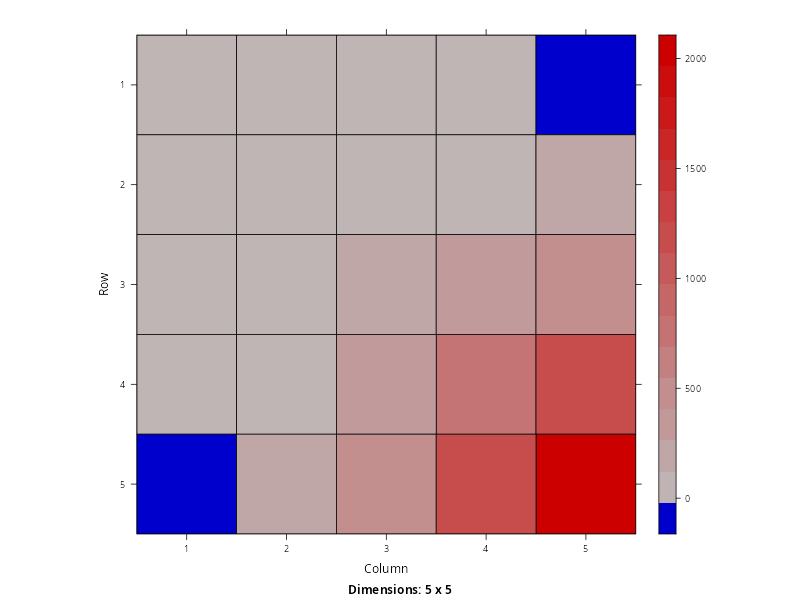

In [13]:
Sigma.1 <- getVarCov(autism.lme, type='marginal', individual='1')$`1`
print(Sigma.1)
image(as(Sigma.1,'Matrix'))

Notably, the variance *increases* as a function of `age`, which is precisely what we desired given the plots from earlier. The correlation structure is a little difficult to understand on the scale of covariance, but we can convert this to correlation using

In [14]:
cov2cor(Sigma.1)

            1           2           3          4           5
1  1.00000000 -0.02441292 -0.05552317 -0.0662298 -0.06821156
2 -0.02441292  1.00000000  0.33970721  0.3931255  0.40171368
3 -0.05552317  0.33970721  1.00000000  0.7978760  0.81590725
4 -0.06622980  0.39312547  0.79787603  1.0000000  0.94768362
5 -0.06821156  0.40171368  0.81590725  0.9476836  1.00000000

This is somewhat curious, as it indicates that socialisation at age 2 is *negatively* correlated with subsequent scores at different ages. For all other ages, the socialisation scores are *positively* correlated with their future values.

## Alternative Models
Before we get to checking assumptions and performing inference, it is a good idea to consider other model forms. Effectively, we want to get to our final model *before* performing these steps. This is both practical, as it prevents multiple confusing round of assumption checking and inference, and is also a guard against *bias*, particularly if we know the results of a given model specification. This sequence is therefore a self-imposed *protection* against being swayed by $p$-values more than the logic of building a sensible model.

### A Quadratic Effect of `age`
As mentioned earlier, there is a slight hint that some of the trajectories are *curved* and so we could consider whether a *quadratic* effect of `age` is warranted. There are three ways this could enter the model: fixed-effects only, random-effects only and both. We will consider all these below in terms of model comparisons using the `BIC()` function. Of importance is that we set `method='ML'`. In addition, we make use of the `update()` function to only change one element of the model specification

In [15]:
autism.lme.null   <- lme(VSAE ~ SICDEGP*age, random=~ 1 + age|childid, data=autism, na.action=na.omit, control=lmeControl(opt='optim', msMaxIter=100), method='ML')
autism.lme.full.1 <- update(autism.lme.null, fixed=VSAE ~ SICDEGP*poly(age,2)) # quadratic fixed
autism.lme.full.2 <- update(autism.lme.null, random=~ 1 + poly(age,2)|childid) # quadratic random
autism.lme.full.3 <- update(autism.lme.null, fixed=VSAE ~ SICDEGP*poly(age,2), random=~ 1 + poly(age,2)|childid) # quadratic fixed & random

mod.comp <- BIC(autism.lme.null,autism.lme.full.1,autism.lme.full.2,autism.lme.full.3)
print(mod.comp)


                  df      BIC
autism.lme.null   10 4767.514
autism.lme.full.1 13 4776.759
autism.lme.full.2 13 4694.026
autism.lme.full.3 16 4706.372


In terms of change in BIC, we can first compare the model with no quadratic terms, to the one with both fixed *and* random quadratic terms

In [16]:
abs(mod.comp$BIC[1] - mod.comp$BIC[4])

[1] 61.14189

which, based on our interpretation given in the ANOVA workshop from last semester, indicates *very strong evidence* in favour of the *lower* BIC model. In this comparison, the lower BIC model is the one with all the quadratic terms, so there is evidence that some sort of curve is beneficial here. Next, we can compare the fixed-only and the random-only to the model with both

In [17]:
print(abs(mod.comp$BIC[2] - mod.comp$BIC[4]))
print(abs(mod.comp$BIC[3] - mod.comp$BIC[4]))

[1] 70.38623
[1] 12.34614


In both cases, this is *very strong* evidence favouring the *lower* BIC model. The first comparison indicates that the model with *both* quadratic effects is better than the model with only a *fixed* quadratic effect. The second comparison indicates that the model with *random only* is better than the model with *both* effects. So, based on this, our final model is

In [18]:
autism.lme <- lme(fixed     = VSAE ~ 1 + SICDEGP + age + SICDEGP:age, 
                  random    = ~ 1 + poly(age,2)|childid,
                  data      = autism, 
                  na.action = na.omit, 
                  control   = lmeControl(opt='optim', msMaxIter=100)
)

Which indicates that the *population-level* effect of `age` is linear, but individual children can diverge from this by curving up and down to various degrees. We can see what effect this has had on the modelled covariance structure

          1          2          3          4          5
1 39.551115   2.144941   5.819979   24.20281   57.29597
2  2.144941  53.979738  44.042993   99.84853  155.58718
3  5.819979  44.042993 158.518409  274.53461  429.29428
4 24.202807  99.848532 274.534606  755.34984 1285.20720
5 57.295970 155.587182 429.294284 1285.20720 2590.31632


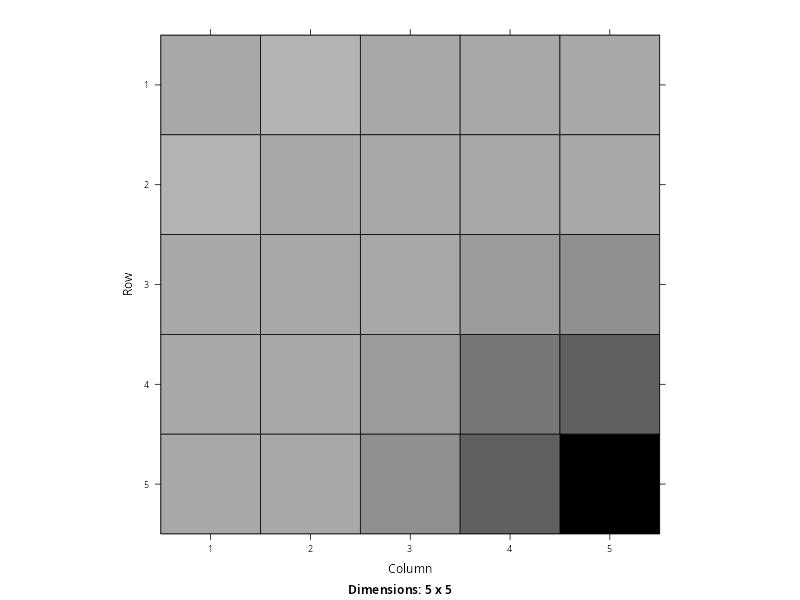

In [19]:
Sigma.1 <- getVarCov(autism.lme, type='marginal', individual='1')$`1`
print(Sigma.1)
image(as(Sigma.1,'Matrix'))

Looking again at the correlation specifically

In [20]:
cov2cor(Sigma.1)

           1          2          3         4         5
1 1.00000000 0.04642166 0.07350252 0.1400272 0.1790063
2 0.04642166 1.00000000 0.47612565 0.4944840 0.4160850
3 0.07350252 0.47612565 1.00000000 0.7933835 0.6699445
4 0.14002717 0.49448398 0.79338352 1.0000000 0.9188036
5 0.17900630 0.41608497 0.66994454 0.9188036 1.0000000

The slightly odd situation with negative correlations has been resolved by allowing the trajectories of individual children to curve, rather than forcing them to be linear.

### Simplifying the Random Effects
At this point, we could also look at simplifying the random effects. Although we saw above that a quadratic model of the child-specific slopes was better than a linear fit, we could also examine whether we need a child-specific effect of `age` at all. Based on reason alone, this *should* be there, but we can see what the data say about this.

In [21]:
autism.lme.null <- lme(VSAE ~ SICDEGP*age, random=~ 1              |childid, data=autism, na.action=na.omit, control=lmeControl(opt='optim', msMaxIter=100), method='ML')
autism.lme.full <- update(autism.lme.null, random=~ 1 + poly(age,2)|childid)

mod.comp <- BIC(autism.lme.null,autism.lme.full)
print(mod.comp)

                df      BIC
autism.lme.null  8 5506.508
autism.lme.full 13 4694.026


We do not even need to calculate the change here to see that we very much do prefer having `age` as a random effect. This confirms our suspicions and demonstrates that our reasoning appeared to be accurate. So, we keep the model with the quadratic effect of `age` as a random slope term.

### Additional Variance Structures
As a final consideration, we can think about whether there are any additional variance structure we may wish to capture. At present, our model is assuming that the variance across the levels of `SICDEGP` is homogenous. So, we could entertain a model that allows these variances to differ. Unfortunately, this is too complex for the data to support. If we try it, we get singular precision errors, which is effectively telling us that there is not enough left-over after fitting the fixed-effects and our complex polynomial random-effects to actually estimate a different variance for each level is `SICDEGP`.

In [22]:
autism.lme.null <- lme(VSAE ~ SICDEGP*age, random=~ 1 + poly(age,2)|childid, data=autism, na.action=na.omit, control=lmeControl(opt='optim', msMaxIter=100), method='ML')
autism.lme.full <- try(update(autism.lme.null, weights=varIdent(form= ~1|SICDEGP)))

Warning messages:
1: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
2: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
3: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
4: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
5: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
6: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
7: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
8: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15
9: In logLik.reStruct(object, conLin) :
  Singular precision matrix in level -1, block 15


So, unfortunately, we will need to abandon this idea and keep the variance homoscedastic. Our final model is then

In [23]:
autism.lme <- lme(fixed     = VSAE ~ 1 + SICDEGP + age + SICDEGP:age, 
                  random    = ~ 1 + poly(age,2)|childid,
                  data      = autism, 
                  na.action = na.omit, 
                  control   = lmeControl(opt='optim', msMaxIter=100)
)

## Checking Assumptions


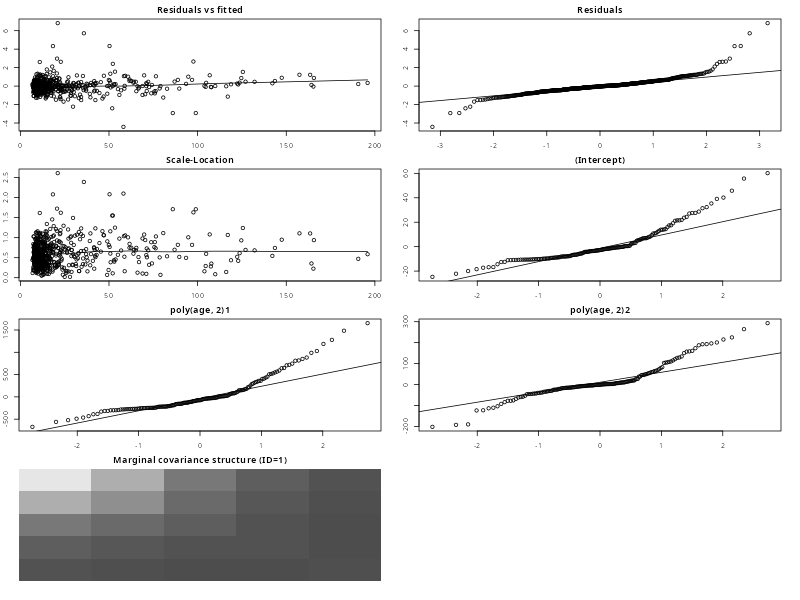

In [24]:
plot.lme(autism.lme, vcov.id='1')

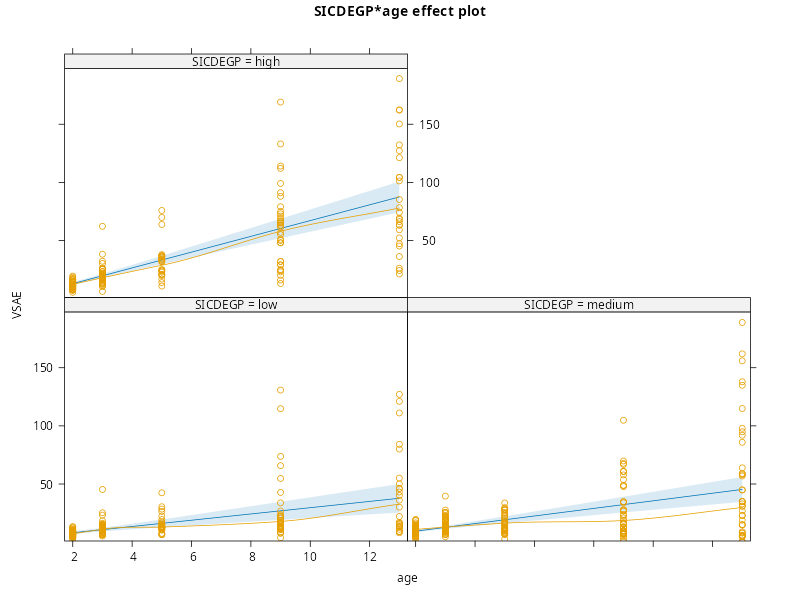

In [25]:
plot(allEffects(autism.lme, residuals=TRUE))

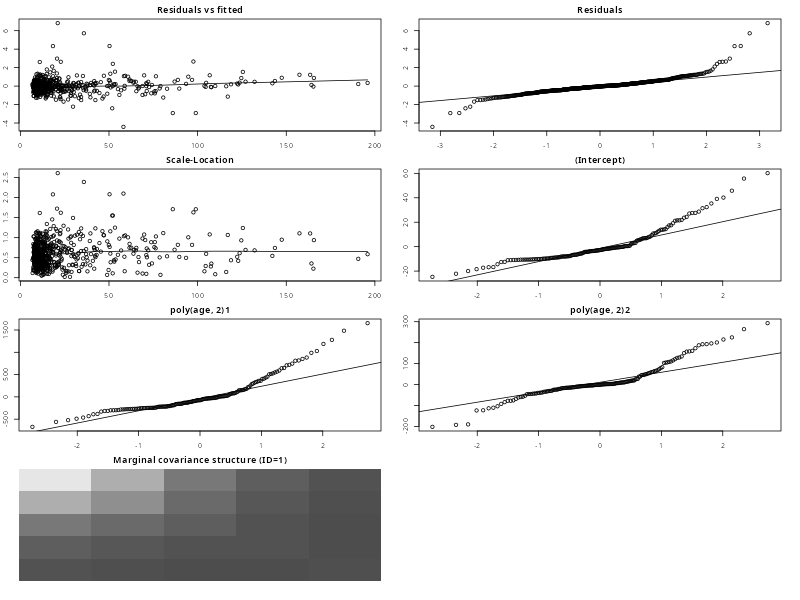

In [26]:
plot.lme(autism.lme, vcov.id='1')

In [27]:
Anova(autism.lme)

Analysis of Deviance Table (Type II tests)

Response: VSAE
              Chisq Df Pr(>Chisq)    
SICDEGP      35.571  2  1.888e-08 ***
age         157.267  1  < 2.2e-16 ***
SICDEGP:age  27.565  2  1.034e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1